# Test_260312_DQN_smallMLP_easiest_holdout\n
\n
Corresponding test notebook for `Train_260312_DQN_smallMLP_easiest.ipynb`.\n
- action space: RU1/RU2/RU3\n
- masked observation: only current connection RU is visible\n
- reward target: selected RU next-slot power

In [2]:
#!/usr/bin/env python3
from __future__ import annotations

import argparse
import random
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from IPython.display import display
import math

STATE_NAMES = ["RU1", "RU2", "RU3", "RU12", "RU13", "RU23"]
N_ACTIONS = 6

RU_ANTS: Dict[int, List[int]] = {
    1: [0, 1],
    2: [2, 3],
    3: [4, 5],
}

STATE_RUS: Dict[int, List[int]] = {
    0: [1],
    1: [2],
    2: [3],
    3: [1, 2],
    4: [1, 3],
    5: [2, 3],
}


class WindowStore:
    def __init__(self, window_dir: str):
        self.window_dir = Path(window_dir)
        x_path = self.window_dir / "X.npz"
        m_path = self.window_dir / "manifest.csv"
        if not x_path.is_file():
            raise FileNotFoundError(f"Missing: {x_path}")
        if not m_path.is_file():
            raise FileNotFoundError(f"Missing: {m_path}")

        self._npz = np.load(str(x_path), mmap_mode="r")
        if "X" not in self._npz:
            raise KeyError(f"'X' not found in {x_path}")
        self.X = self._npz["X"]

        if self.X.ndim != 3 or self.X.shape[-1] != 6:
            raise ValueError(f"Expected X shape (N,L,6), got {self.X.shape}")

        self.N = int(self.X.shape[0])
        self.L = int(self.X.shape[1])
        self.dt = float(self._npz["dt"]) if "dt" in self._npz else 0.005

        self.manifest = pd.read_csv(str(m_path))
        if "sample_id" not in self.manifest.columns:
            self.manifest["sample_id"] = np.arange(self.N, dtype=int)
        self.manifest = self.manifest.sort_values("sample_id").reset_index(drop=True)
        if len(self.manifest) != self.N:
            raise ValueError(f"manifest rows ({len(self.manifest)}) != X windows N ({self.N})")

    def __len__(self) -> int:
        return self.N

    def get_window_gains(self, idx: int) -> np.ndarray:
        H = np.array(self.X[int(idx)], copy=False)
        g = np.abs(H).astype(np.float32)
        bad = ~np.isfinite(g)
        if np.any(bad):
            g[bad] = 0.0
        return g


@dataclass
class EnvConfig:
    seg_len_ticks: int = 20
    obs_bin_ticks: int = 20
    obs_hist_bins: int = 3
    mask_value: float = 0.0
    handover_penalty: float = 5e-4
    inter_ru_phase_noise_std: float = math.pi / 8.0
    noise_power: float = 1e-3
    max_episode_steps: int = 0


class RUWindowEnv:
    def __init__(self, store: WindowStore, cfg: EnvConfig):
        self.store = store
        self.cfg = cfg

        self.obs_dim = 3 * self.cfg.obs_hist_bins + N_ACTIONS
        self.n_actions = N_ACTIONS

        self._g: Optional[np.ndarray] = None
        self._ep_idx: int = -1
        self._seg_k: int = 0
        self._n_segs: int = 0
        self._steps: int = 0
        self._max_steps_this_ep: int = 0
        self._conn_state: int = 0
        self._conn_hist: List[int] = []

    def reset(self, ep_idx: int) -> np.ndarray:
        g = self.store.get_window_gains(int(ep_idx))
        L = g.shape[0]
        segL = int(self.cfg.seg_len_ticks)
        if (L % segL) != 0:
            raise ValueError(f"Window length L={L} not divisible by seg_len_ticks={segL}")

        n_segs = L // segL
        if n_segs < 2:
            raise ValueError(f"Window too short: n_segs={n_segs} < 2")

        self._g = g
        self._ep_idx = int(ep_idx)
        self._seg_k = 0
        self._n_segs = int(n_segs)
        self._steps = 0
        self._conn_state = int(np.random.choice(list(range(N_ACTIONS))))
        self._conn_hist = [int(self._conn_state)]

        default_full = self._n_segs - 1
        if int(self.cfg.max_episode_steps) <= 0:
            self._max_steps_this_ep = default_full
        else:
            self._max_steps_this_ep = min(int(self.cfg.max_episode_steps), default_full)

        return self._make_obs()

    def _seg_slice(self, seg_idx: int) -> slice:
        segL = int(self.cfg.seg_len_ticks)
        a = seg_idx * segL
        b = a + segL
        return slice(a, b)

    def ru_gain_segment(self, seg_idx: int) -> np.ndarray:
        assert self._g is not None
        seg = self._g[self._seg_slice(seg_idx), :]
        g1 = np.sqrt(np.maximum(seg[:, 0] ** 2 + seg[:, 1] ** 2, 0.0)).mean()
        g2 = np.sqrt(np.maximum(seg[:, 2] ** 2 + seg[:, 3] ** 2, 0.0)).mean()
        g3 = np.sqrt(np.maximum(seg[:, 4] ** 2 + seg[:, 5] ** 2, 0.0)).mean()
        return np.array([g1, g2, g3], dtype=np.float32)

    def all_state_power_segment(self, seg_idx: int) -> np.ndarray:
        assert self._g is not None
        seg = self._g[self._seg_slice(seg_idx), :].astype(np.float64)

        p1_t = seg[:, 0] ** 2 + seg[:, 1] ** 2
        p2_t = seg[:, 2] ** 2 + seg[:, 3] ** 2
        p3_t = seg[:, 4] ** 2 + seg[:, 5] ** 2

        p1 = float(np.mean(p1_t))
        p2 = float(np.mean(p2_t))
        p3 = float(np.mean(p3_t))

        phase_std = float(self.cfg.inter_ru_phase_noise_std)

        def pair_power(pa_t: np.ndarray, pb_t: np.ndarray) -> float:
            a = np.sqrt(np.maximum(pa_t, 0.0) * 0.5)
            b = np.sqrt(np.maximum(pb_t, 0.0) * 0.5)
            dphi = np.random.normal(0.0, phase_std, size=a.shape)
            p = a * a + b * b + 2.0 * a * b * np.cos(dphi)
            return float(np.mean(p))

        p12 = pair_power(p1_t, p2_t)
        p13 = pair_power(p1_t, p3_t)
        p23 = pair_power(p2_t, p3_t)

        power = np.array([p1, p2, p3, p12, p13, p23], dtype=np.float32)
        return np.log2(1.0 + power / float(self.cfg.noise_power))

    def _make_obs(self) -> np.ndarray:
        B = int(self.cfg.obs_hist_bins)
        obs = np.full((3, B), float(self.cfg.mask_value), dtype=np.float32)

        for bi in range(B):
            seg_idx = int(self._seg_k) - (B - bi)
            seg_idx = max(0, min(seg_idx, self._n_segs - 1))
            full = self.ru_gain_segment(seg_idx).astype(np.float32)

            hist_idx = max(0, min(seg_idx, len(self._conn_hist) - 1))
            conn_state_seg = int(self._conn_hist[hist_idx])
            for ru in STATE_RUS[conn_state_seg]:
                obs[ru - 1, bi] = full[ru - 1]

        conn_oh = np.zeros((N_ACTIONS,), dtype=np.float32)
        conn_oh[int(self._conn_state)] = 1.0
        return np.concatenate([obs.reshape(-1).astype(np.float32), conn_oh], axis=0)

    def step(self, action: int) -> Tuple[np.ndarray, float, bool, Dict]:
        assert self._g is not None
        action = int(np.clip(int(action), 0, N_ACTIONS - 1))

        obs_seg = int(self._seg_k)
        conn_before = int(self._conn_state)
        rew_seg = obs_seg + 1

        state_power = self.all_state_power_segment(rew_seg)
        handover_attempt = 1 if (int(action) != int(conn_before)) else 0
        reward = float(state_power[action]) - float(self.cfg.handover_penalty) * float(handover_attempt)

        self._conn_state = int(action)
        self._seg_k += 1
        self._steps += 1

        if len(self._conn_hist) <= int(self._seg_k):
            self._conn_hist.append(int(self._conn_state))

        done = (self._steps >= self._max_steps_this_ep)
        obs = self._make_obs()

        info = {
            "window_index": int(self._ep_idx),
            "seg_k": int(self._seg_k),
            "obs_seg": int(obs_seg),
            "reward_seg": int(rew_seg),
            "action": int(action),
            "reward": float(reward),
            "selected_state_power": float(state_power[action]),
            "best_state_power": float(np.max(state_power)),
            "is_best_action": int(action == int(np.argmax(state_power))),
            "handover_attempt": int(handover_attempt),
            "conn_state_before": int(conn_before),
            "conn_state_after": int(self._conn_state),
        }
        return obs, reward, done, info


class GRUQNetwork(nn.Module):
    def __init__(self, obs_dim: int, hidden_size: int, n_actions: int):
        super().__init__()
        self.obs_dim = int(obs_dim)
        self.hidden_size = int(hidden_size)
        self.n_actions = int(n_actions)

        self.gru = nn.GRUCell(input_size=self.obs_dim, hidden_size=self.hidden_size)
        self.q_head = nn.Linear(self.hidden_size, self.n_actions)
        self.h0 = nn.Parameter(torch.zeros(self.hidden_size))

    def init_hidden(self, batch: int, device: torch.device) -> torch.Tensor:
        return self.h0.view(1, -1).expand(batch, -1).to(device)

    def forward(self, obs: torch.Tensor, h: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        h_next = self.gru(obs, h)
        q = self.q_head(h_next)
        return q, h_next


class MLPQNetwork(nn.Module):
    def __init__(self, obs_dim: int, h1: int, h2: int, n_actions: int):
        super().__init__()
        self.obs_dim = int(obs_dim)
        self.n_actions = int(n_actions)
        self.net = nn.Sequential(
            nn.Linear(int(obs_dim), int(h1)),
            nn.ReLU(),
            nn.Linear(int(h1), int(h2)),
            nn.ReLU(),
            nn.Linear(int(h2), int(n_actions)),
        )

    def forward(self, obs: torch.Tensor) -> torch.Tensor:
        return self.net(obs)


def make_device(use_cpu: bool, gpu_id: int) -> torch.device:
    if (not use_cpu) and torch.cuda.is_available():
        return torch.device(f"cuda:{gpu_id}")
    return torch.device("cpu")


def load_checkpoint_and_model(ckpt_path: str, device: torch.device) -> Tuple[dict, nn.Module]:
    ckpt = torch.load(ckpt_path, map_location="cpu")
    if "q_net" not in ckpt:
        raise KeyError("Checkpoint does not contain 'q_net'. Expected DQN checkpoint.")

    sd = ckpt["q_net"]
    if any(k.startswith("gru.") for k in sd.keys()):
        meta = ckpt.get("model_meta", {})
        if meta:
            obs_dim = int(meta.get("obs_dim", sd["gru.weight_ih"].shape[1]))
            hidden_size = int(meta.get("hidden_size", sd["gru.weight_hh"].shape[1]))
            n_actions = int(meta.get("n_actions", sd["q_head.weight"].shape[0]))
        else:
            obs_dim = int(sd["gru.weight_ih"].shape[1])
            hidden_size = int(sd["gru.weight_hh"].shape[1])
            n_actions = int(sd["q_head.weight"].shape[0])

        model = GRUQNetwork(obs_dim=obs_dim, hidden_size=hidden_size, n_actions=n_actions).to(device)
        model.load_state_dict(sd, strict=True)
        model.eval()
        print(f"[MODEL] GRU obs_dim={obs_dim} hidden={hidden_size} actions={n_actions}")
        return ckpt, model

    if all(k in sd for k in ["net.0.weight", "net.0.bias", "net.2.weight", "net.2.bias", "net.4.weight", "net.4.bias"]):
        obs_dim = int(sd["net.0.weight"].shape[1])
        h1 = int(sd["net.0.weight"].shape[0])
        h2 = int(sd["net.2.weight"].shape[0])
        n_actions = int(sd["net.4.weight"].shape[0])

        model = MLPQNetwork(obs_dim=obs_dim, h1=h1, h2=h2, n_actions=n_actions).to(device)
        model.load_state_dict(sd, strict=True)
        model.eval()
        print(f"[MODEL] MLP obs_dim={obs_dim} h1={h1} h2={h2} actions={n_actions}")
        return ckpt, model

    raise ValueError("Unsupported q_net architecture in checkpoint.")


def decide_action(policy_name: str, env: RUWindowEnv, obs: np.ndarray, model: Optional[nn.Module], h: Optional[torch.Tensor], device: torch.device) -> Tuple[int, Optional[torch.Tensor]]:
    if policy_name == "model_greedy":
        assert model is not None
        obs_t = torch.from_numpy(obs).to(device).view(1, -1)
        with torch.no_grad():
            if isinstance(model, GRUQNetwork):
                assert h is not None
                q, h_next = model(obs_t, h)
                a = int(torch.argmax(q, dim=-1).item())
                return a, h_next
            q = model(obs_t)
            a = int(torch.argmax(q, dim=-1).item())
            return a, h

    if policy_name == "random":
        return int(np.random.randint(0, N_ACTIONS)), h

    if policy_name == "oracle_next_power":
        seg = int(env._seg_k) + 1
        p = env.all_state_power_segment(seg)
        conn_before = int(env._conn_state)
        score = p - float(env.cfg.handover_penalty) * np.array([0 if a == conn_before else 1 for a in range(N_ACTIONS)], dtype=np.float32)
        return int(np.argmax(score)), h

    if policy_name.startswith("fixed_"):
        tag = policy_name.split("_", 1)[1]
        return int(STATE_NAMES.index(tag)), h

    raise ValueError(f"Unknown policy_name={policy_name}")


def run_episode(env: RUWindowEnv, ep_idx: int, policy_name: str, model: Optional[nn.Module], device: torch.device, keep_trace: bool = False) -> Dict:
    obs = env.reset(ep_idx=ep_idx)
    h = model.init_hidden(1, device) if (model is not None and policy_name == "model_greedy" and isinstance(model, GRUQNetwork)) else None

    recs: List[Dict] = []
    done = False
    ep_return = 0.0
    ep_best_sum = 0.0
    ep_ho_sum = 0.0
    steps = 0

    while not done:
        k = int(env._seg_k)
        obs_full = env.ru_gain_segment(k)
        next_power = env.all_state_power_segment(k + 1)

        action, h = decide_action(policy_name, env, obs, model, h, device)
        obs2, reward, done, info = env.step(action)

        ep_return += float(reward)
        ep_best_sum += float(info["is_best_action"])
        ep_ho_sum += float(info["handover_attempt"])
        steps += 1

        if keep_trace:
            recs.append(
                {
                    "step": steps - 1,
                    "action": int(action),
                    "reward": float(reward),
                    "is_best_action": int(info["is_best_action"]),
                    "handover_attempt": int(info["handover_attempt"]),
                    "obs_ru1": float(obs[:9].reshape(3, -1)[0, -1]),
                    "obs_ru2": float(obs[:9].reshape(3, -1)[1, -1]),
                    "obs_ru3": float(obs[:9].reshape(3, -1)[2, -1]),
                    "full_ru1": float(obs_full[0]),
                    "full_ru2": float(obs_full[1]),
                    "full_ru3": float(obs_full[2]),
                    "next_p_ru1": float(next_power[0]),
                    "next_p_ru2": float(next_power[1]),
                    "next_p_ru3": float(next_power[2]),
                    "next_p_ru12": float(next_power[3]),
                    "next_p_ru13": float(next_power[4]),
                    "next_p_ru23": float(next_power[5]),
                }
            )
        obs = obs2

    out = {
        "window_index": int(ep_idx),
        "n_steps": int(steps),
        "reward_per_step": float(ep_return / max(steps, 1)),
        "best_action_ratio": float(ep_best_sum / max(steps, 1)),
        "handover_per_step": float(ep_ho_sum / max(steps, 1)),
    }
    if keep_trace:
        out["trace"] = recs
    return out


def evaluate_policy(store: WindowStore, env_cfg: EnvConfig, indices: List[int], policy_name: str, model: Optional[nn.Module], device: torch.device) -> pd.DataFrame:
    env = RUWindowEnv(store=store, cfg=env_cfg)
    rows = []
    for ep_idx in indices:
        rows.append(run_episode(env, int(ep_idx), policy_name, model, device, keep_trace=False))
    return pd.DataFrame(rows)


def summarize_policy(df: pd.DataFrame, policy_name: str, split_name: str) -> Dict:
    return {
        "split": split_name,
        "policy": policy_name,
        "n_episodes": int(len(df)),
        "reward_mean_per_step": float(df["reward_per_step"].mean()),
        "best_action_ratio": float(df["best_action_ratio"].mean()),
        "handover_per_step": float(df["handover_per_step"].mean()),
    }


def plot_trajectory_inline(trace: Dict, store: WindowStore, split_name: str, dataset_name: str, seg_len_ticks: int):
    recs = trace["trace"]
    ep_idx = int(trace["window_index"])

    t = np.arange(len(recs)) * (store.dt * float(seg_len_ticks))
    actions = np.array([r["action"] for r in recs], dtype=int)

    full1 = np.array([r["full_ru1"] for r in recs], dtype=float)
    full2 = np.array([r["full_ru2"] for r in recs], dtype=float)
    full3 = np.array([r["full_ru3"] for r in recs], dtype=float)

    nextp1 = np.array([r["next_p_ru1"] for r in recs], dtype=float)
    nextp2 = np.array([r["next_p_ru2"] for r in recs], dtype=float)
    nextp3 = np.array([r["next_p_ru3"] for r in recs], dtype=float)

    obs1 = np.array([r["obs_ru1"] for r in recs], dtype=float)
    obs2 = np.array([r["obs_ru2"] for r in recs], dtype=float)
    obs3 = np.array([r["obs_ru3"] for r in recs], dtype=float)

    fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

    axes[0].plot(t, full1, label="Full RU1 gain", lw=1.8)
    axes[0].plot(t, full2, label="Full RU2 gain", lw=1.8)
    axes[0].plot(t, full3, label="Full RU3 gain", lw=1.8)
    axes[0].plot(t, obs1, "--", alpha=0.8, label="Obs RU1 (masked, latest bin)")
    axes[0].plot(t, obs2, "--", alpha=0.8, label="Obs RU2 (masked, latest bin)")
    axes[0].plot(t, obs3, "--", alpha=0.8, label="Obs RU3 (masked, latest bin)")
    axes[0].set_ylabel("Gain")
    axes[0].set_title(f"[{split_name}] window={ep_idx} | dataset={dataset_name}")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend(loc="upper right", ncol=2)

    axes[1].plot(t, nextp1, label="Next RU1 power", lw=2)
    axes[1].plot(t, nextp2, label="Next RU2 power", lw=2)
    axes[1].plot(t, nextp3, label="Next RU3 power", lw=2)
    axes[1].set_ylabel("Next-Slot Power")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend(loc="upper right")

    axes[2].step(t, actions, where="post", lw=2, label="Selected action")
    axes[2].set_yticks(np.arange(N_ACTIONS))
    axes[2].set_yticklabels(STATE_NAMES)
    axes[2].set_ylabel("Action")
    axes[2].set_xlabel("Time (s)")
    axes[2].grid(True, alpha=0.3)
    axes[2].legend(loc="upper right")

    fig.tight_layout()
    plt.show()


def plot_policy_comparison_inline(df_cmp: pd.DataFrame, split_name: str):
    show = df_cmp[df_cmp["split"] == split_name].copy()
    show = show.sort_values("reward_mean_per_step", ascending=False).reset_index(drop=True)
    x = np.arange(len(show))

    fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)
    axes[0].bar(x, show["reward_mean_per_step"].to_numpy())
    axes[0].set_ylabel("Reward/step")
    axes[0].set_title(f"Policy Comparison ({split_name})")
    axes[0].grid(True, axis="y", alpha=0.3)

    axes[1].bar(x, show["best_action_ratio"].to_numpy())
    axes[1].set_ylabel("Best Action Ratio")
    axes[1].grid(True, axis="y", alpha=0.3)

    axes[2].bar(x, show["handover_per_step"].to_numpy())
    axes[2].set_ylabel("Handover/step")
    axes[2].grid(True, axis="y", alpha=0.3)
    axes[2].set_xticks(x)
    axes[2].set_xticklabels(show["policy"].tolist(), rotation=20, ha="right")

    fig.tight_layout()
    plt.show()


def main(argv: Optional[List[str]] = None):
    ap = argparse.ArgumentParser(description="Test DQN-smallGRU-easiest model on train/test scenarios.")
    ap.add_argument("--ckpt", type=str, required=True)
    ap.add_argument("--seed", type=int, default=123)
    ap.add_argument("--cpu", action="store_true", default=False)
    ap.add_argument("--gpu-id", type=int, default=3)
    ap.add_argument("--num-scenarios", type=int, default=20)
    args, unknown = ap.parse_known_args(argv)
    if unknown:
        print("[ARGS] Ignoring unknown args (likely Jupyter):", unknown)

    random.seed(args.seed)
    np.random.seed(args.seed)
    torch.manual_seed(args.seed)
    torch.cuda.manual_seed_all(args.seed)

    device = make_device(use_cpu=bool(args.cpu), gpu_id=int(args.gpu_id))
    print(f"[DEVICE] {device}")

    ckpt, model = load_checkpoint_and_model(args.ckpt, device)

    model_n_actions = int(getattr(model, "n_actions", -1))
    if model_n_actions != N_ACTIONS:
        raise ValueError(
            f"Checkpoint/action mismatch: model has {model_n_actions} actions but this test code expects {N_ACTIONS} "
            f"(RU1,RU2,RU3,RU12,RU13,RU23). Use a 6-action checkpoint trained with Final_Train_260316."
        )

    store = WindowStore(str(ckpt["window_dir"]))
    env_raw = dict(ckpt.get("env_cfg", {}))
    valid_keys = set(EnvConfig.__dataclass_fields__.keys())
    env_cfg = EnvConfig(**{k: env_raw[k] for k in env_raw.keys() if k in valid_keys})

    expected_obs_dim = 3 * int(env_cfg.obs_hist_bins) + N_ACTIONS
    model_obs_dim = int(getattr(model, "obs_dim", expected_obs_dim))
    if model_obs_dim != expected_obs_dim:
        if model_obs_dim >= N_ACTIONS and ((model_obs_dim - N_ACTIONS) % 3 == 0):
            env_cfg.obs_hist_bins = int((model_obs_dim - N_ACTIONS) // 3)
            expected_obs_dim = 3 * int(env_cfg.obs_hist_bins) + N_ACTIONS
            print(f"[ENV] adjusted obs_hist_bins to {env_cfg.obs_hist_bins} to match checkpoint obs_dim={model_obs_dim}")
        else:
            raise ValueError(
                f"Checkpoint/obs mismatch: model obs_dim={model_obs_dim}, but env obs_dim={expected_obs_dim}."
            )

    test_indices = list(map(int, ckpt.get("test_indices", [])))
    train_indices = list(map(int, ckpt.get("train_indices", [])))
    if len(test_indices) == 0 or len(train_indices) == 0:
        raise ValueError("Checkpoint must contain both train_indices and test_indices.")

    print(f"[DATA] window_dir={ckpt['window_dir']}")
    print(f"[DATA] X shape={store.X.shape} dt={store.dt:.6f}s")
    print(f"[ENV] seg_len_ticks={env_cfg.seg_len_ticks} obs_dim={3 * env_cfg.obs_hist_bins + N_ACTIONS} actions={N_ACTIONS}")

    n_total = max(int(args.num_scenarios), 20)
    n_test = min(len(test_indices), max(1, n_total // 2))
    n_train = min(len(train_indices), max(1, n_total - n_test))
    while (n_test + n_train) < n_total:
        if n_test < len(test_indices):
            n_test += 1
        elif n_train < len(train_indices):
            n_train += 1
        else:
            break

    rng = np.random.RandomState(args.seed)
    pick_test = sorted(rng.choice(np.array(test_indices, dtype=np.int64), size=n_test, replace=False).tolist())
    pick_train = sorted(rng.choice(np.array(train_indices, dtype=np.int64), size=n_train, replace=False).tolist())

    print(f"[SCENARIOS] showing test={len(pick_test)} + train={len(pick_train)} = {len(pick_test) + len(pick_train)}")

    env = RUWindowEnv(store=store, cfg=env_cfg)

    print("\n[DISPLAY] TEST scenarios")
    for ep_idx in pick_test:
        res = run_episode(env, int(ep_idx), "model_greedy", model, device, keep_trace=True)
        dataset_name = str(store.manifest.loc[int(ep_idx), "dataset"]) if "dataset" in store.manifest.columns else "unknown"
        plot_trajectory_inline(res, store, split_name="test", dataset_name=dataset_name, seg_len_ticks=int(env_cfg.seg_len_ticks))

    print("\n[DISPLAY] TRAIN scenarios")
    for ep_idx in pick_train:
        res = run_episode(env, int(ep_idx), "model_greedy", model, device, keep_trace=True)
        dataset_name = str(store.manifest.loc[int(ep_idx), "dataset"]) if "dataset" in store.manifest.columns else "unknown"
        plot_trajectory_inline(res, store, split_name="train", dataset_name=dataset_name, seg_len_ticks=int(env_cfg.seg_len_ticks))

    baselines = ["model_greedy", "random", "fixed_RU1", "fixed_RU2", "fixed_RU3", "fixed_RU12", "fixed_RU13", "fixed_RU23", "oracle_next_power"]
    rows = []
    for split_name, idxs in [("test", test_indices), ("train", train_indices)]:
        for p in baselines:
            mdl = model if p == "model_greedy" else None
            df = evaluate_policy(store, env_cfg, idxs, p, mdl, device)
            rows.append(summarize_policy(df, p, split_name))

    df_cmp = pd.DataFrame(rows)
    print("\n[COMPARISON TABLE]")
    display(df_cmp.sort_values(["split", "reward_mean_per_step"], ascending=[True, False]).reset_index(drop=True))

    print("\n[COMPARISON PLOTS] test")
    plot_policy_comparison_inline(df_cmp, split_name="test")
    print("[COMPARISON PLOTS] train")
    plot_policy_comparison_inline(df_cmp, split_name="train")

    print("[DONE] Displayed sampled trajectories and comparison plots inline.")


[DEVICE] cuda:3
[MODEL] GRU obs_dim=15 hidden=8 actions=6
[DATA] window_dir=/home/cbchae/MoonHyungJoo/Research_D-MIMO/data_ready/windows_ws4p00s_ov8
[DATA] X shape=(1504, 800, 6) dt=0.005000s
[ENV] seg_len_ticks=20 obs_dim=15 actions=6
[SCENARIOS] showing test=10 + train=10 = 20

[DISPLAY] TEST scenarios


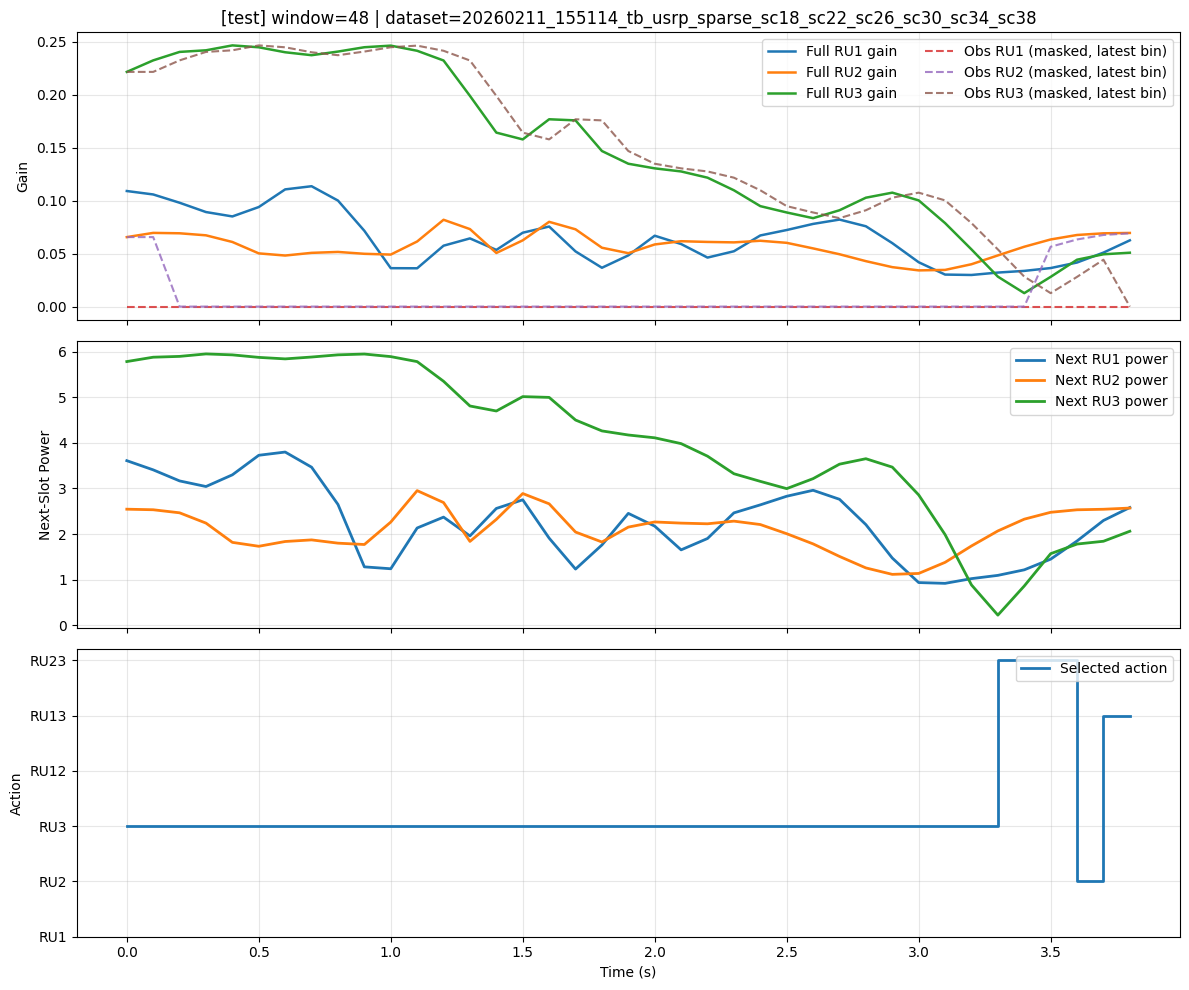

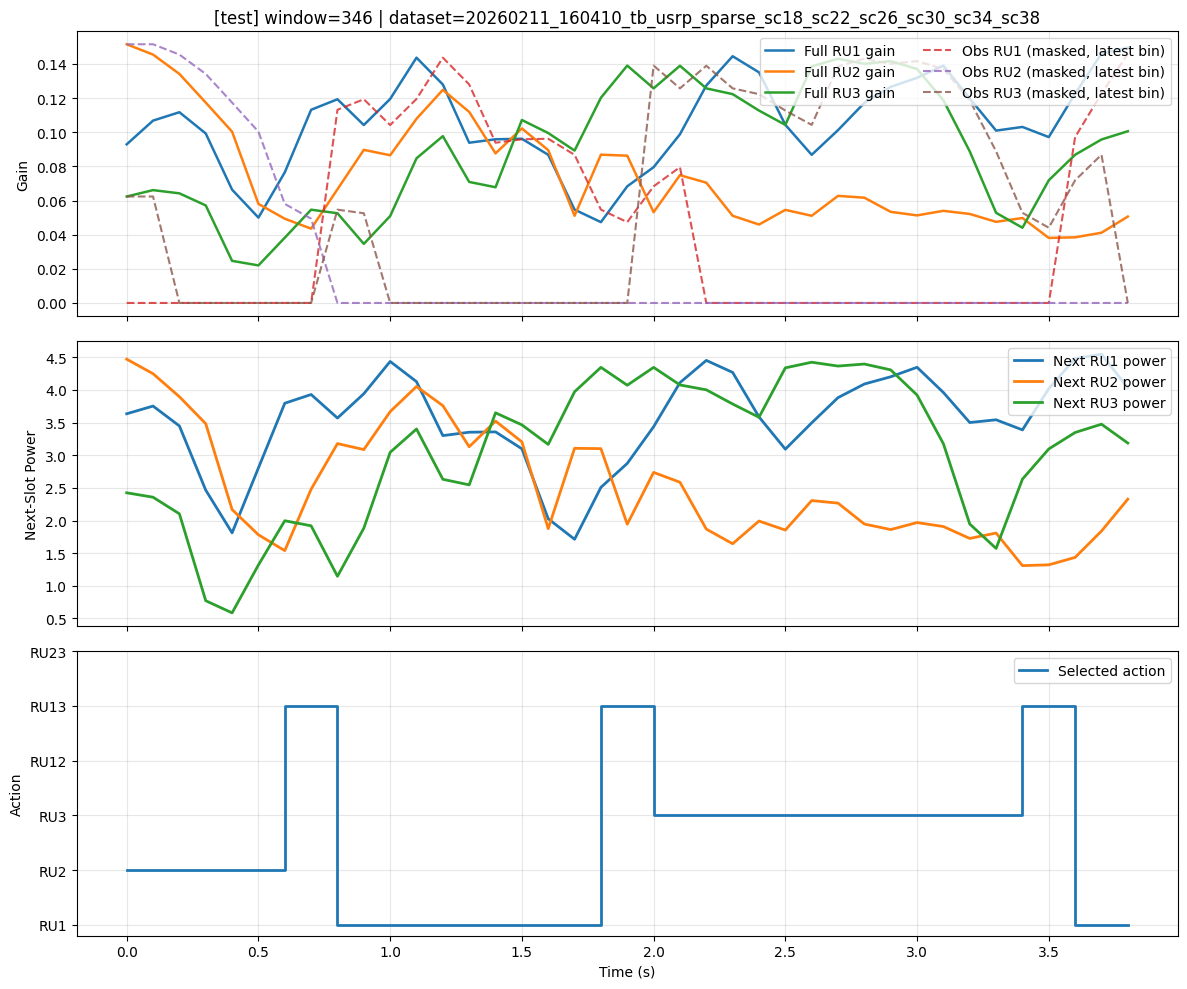

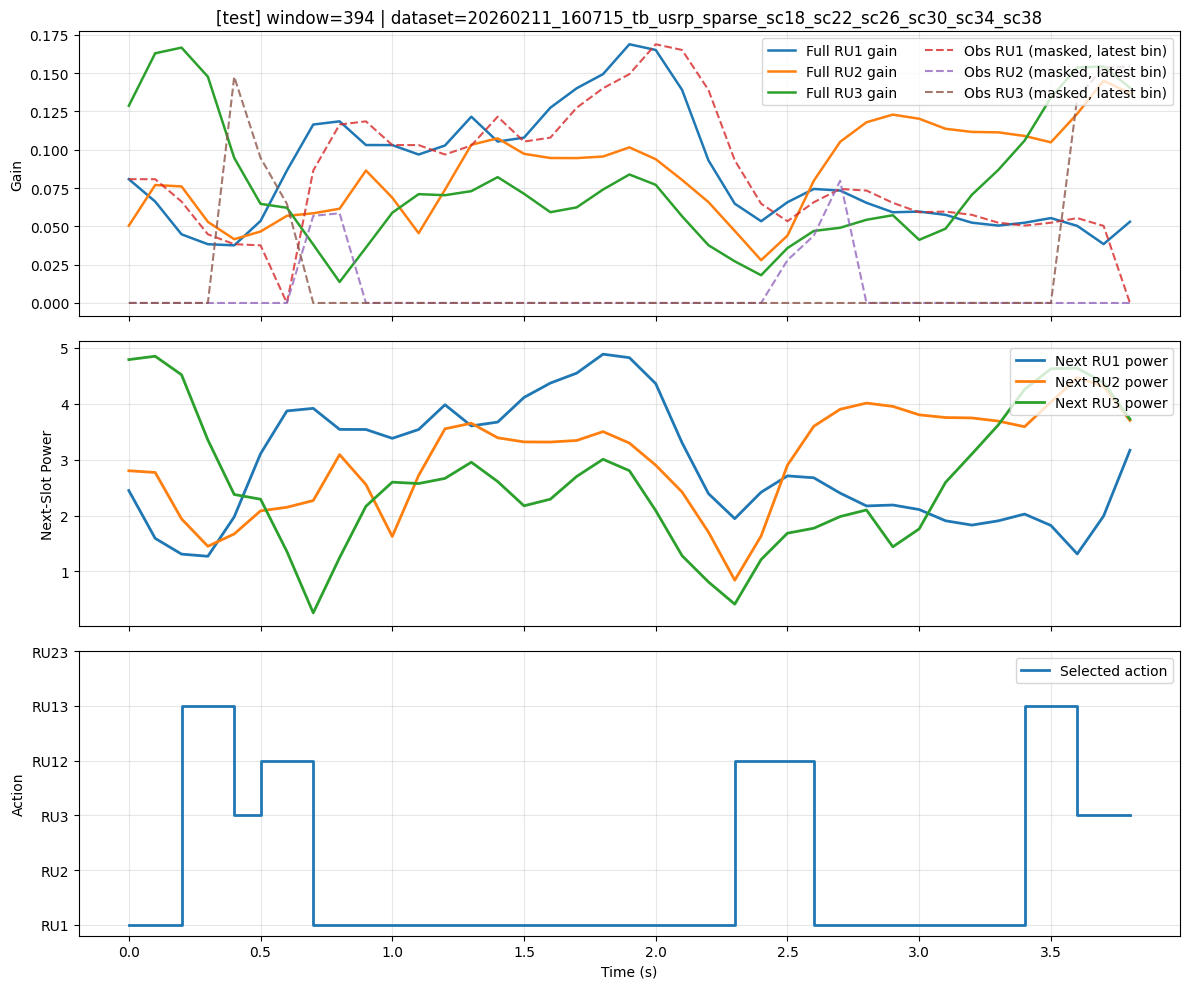

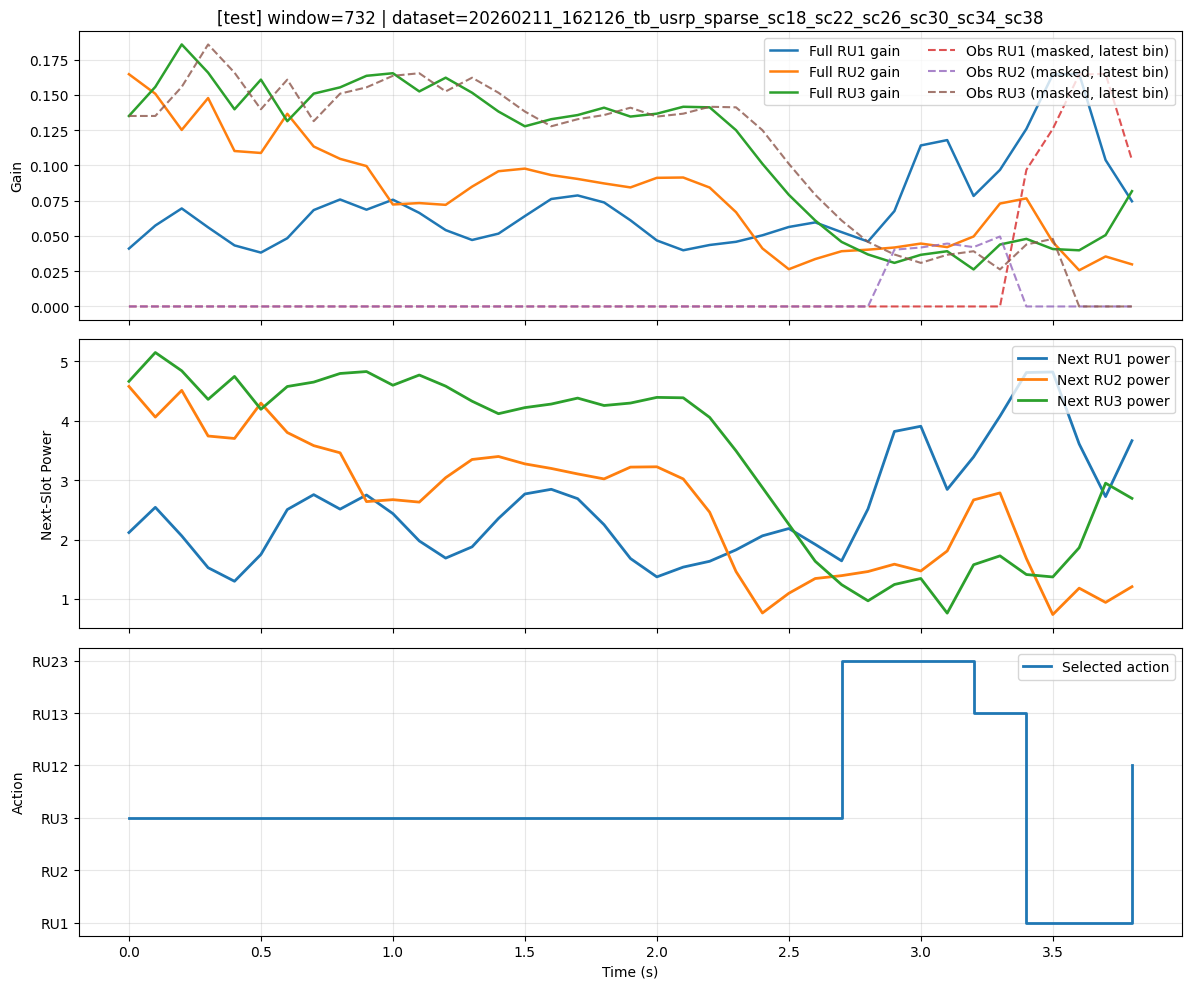

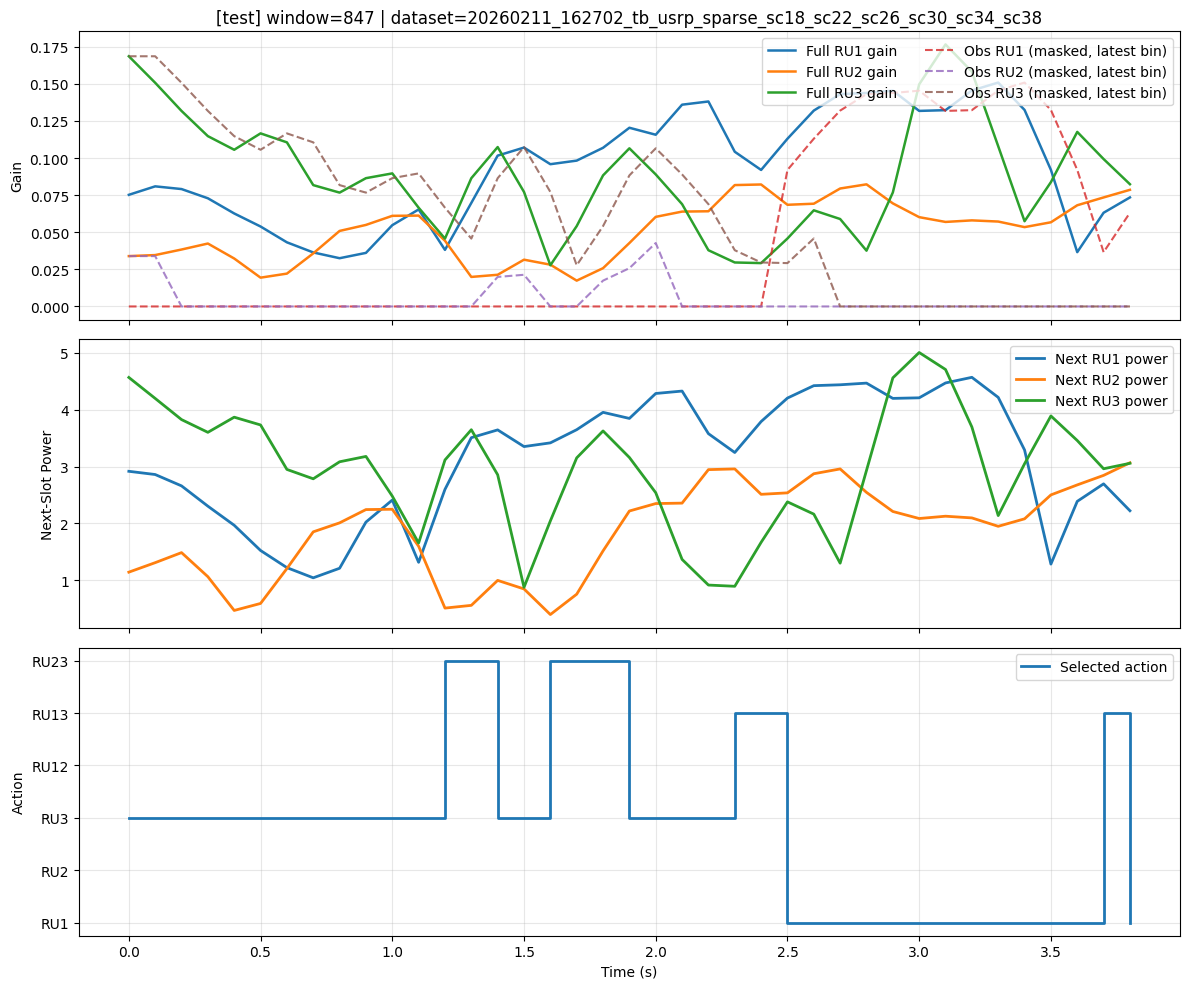

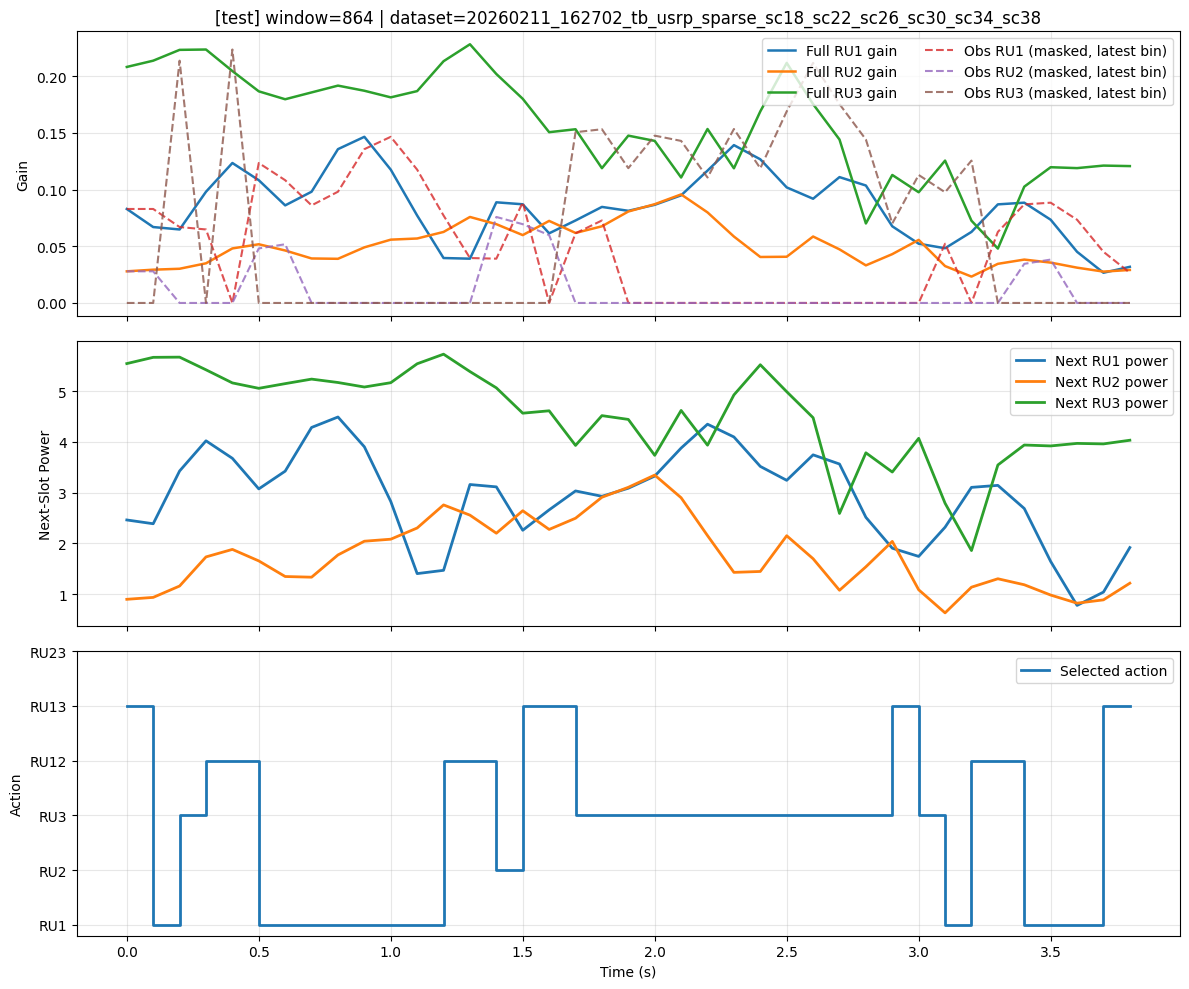

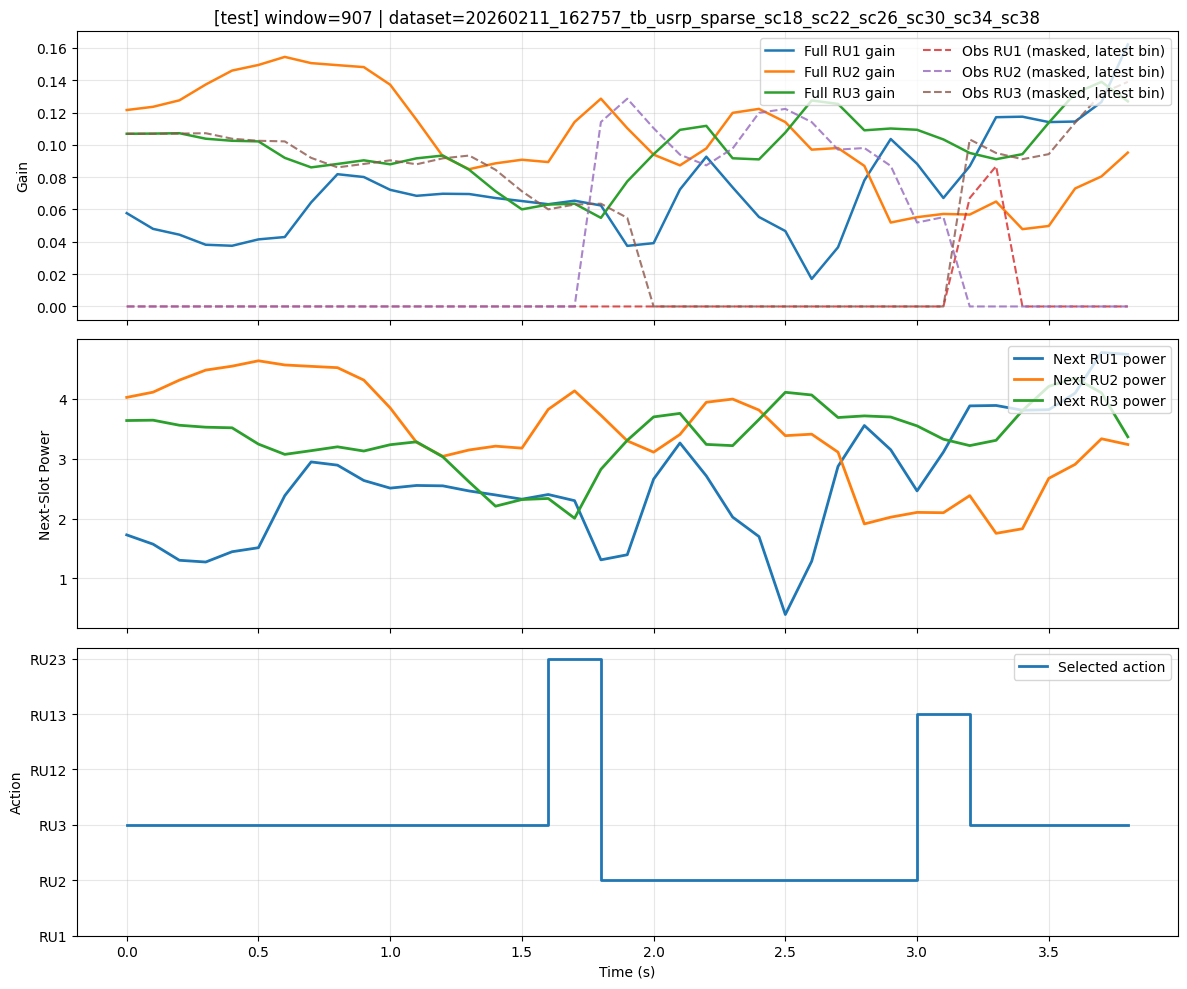

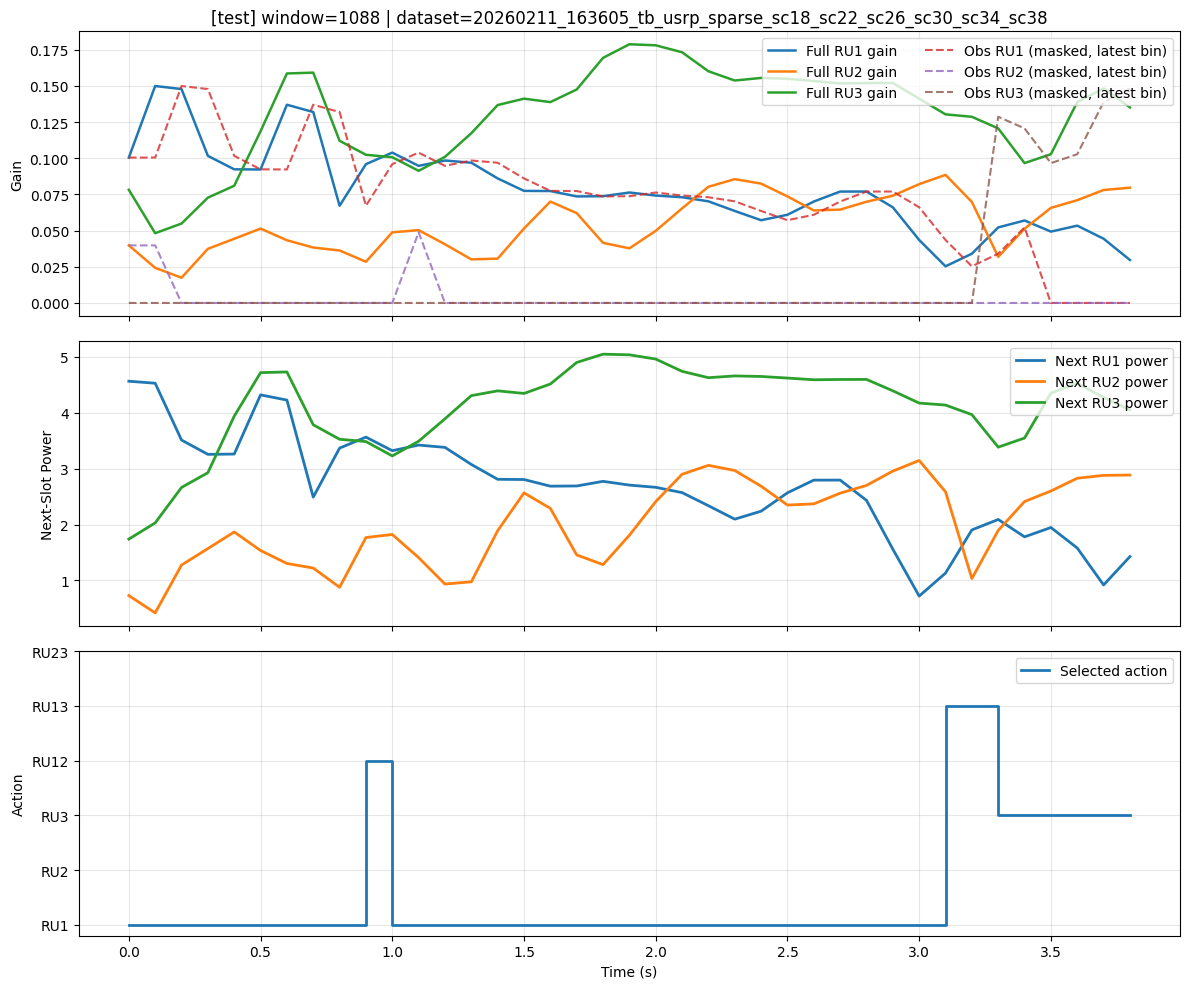

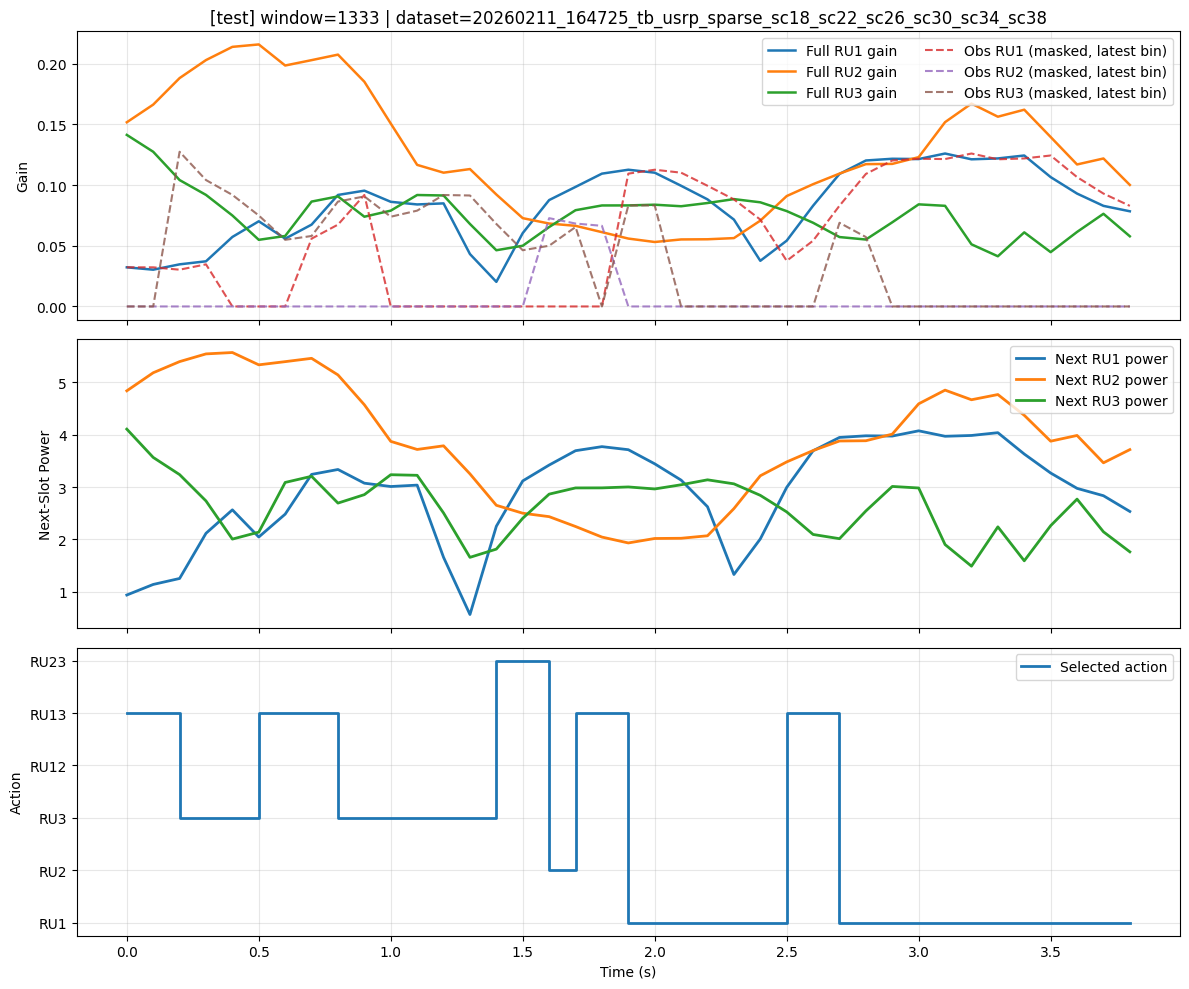

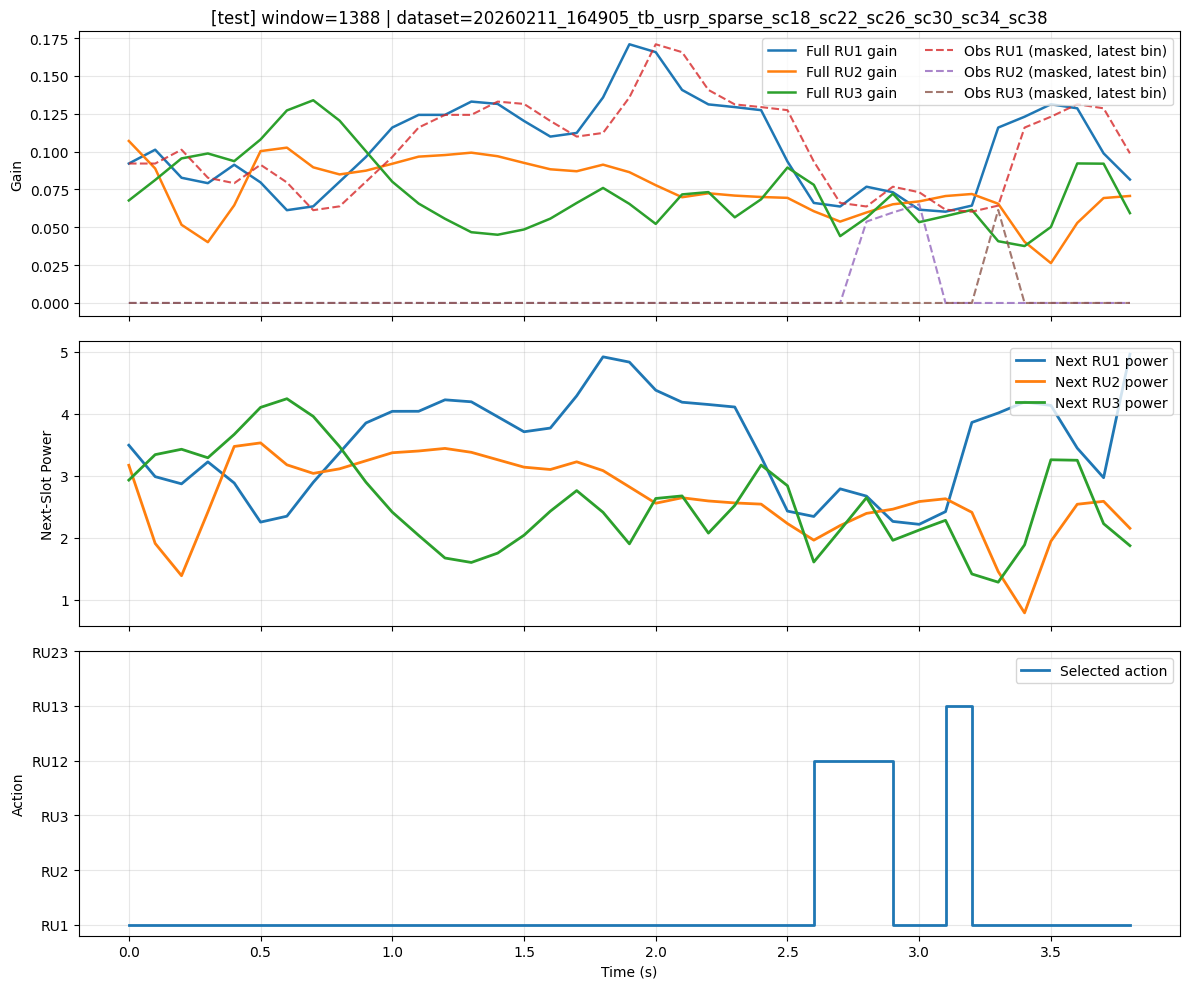


[DISPLAY] TRAIN scenarios


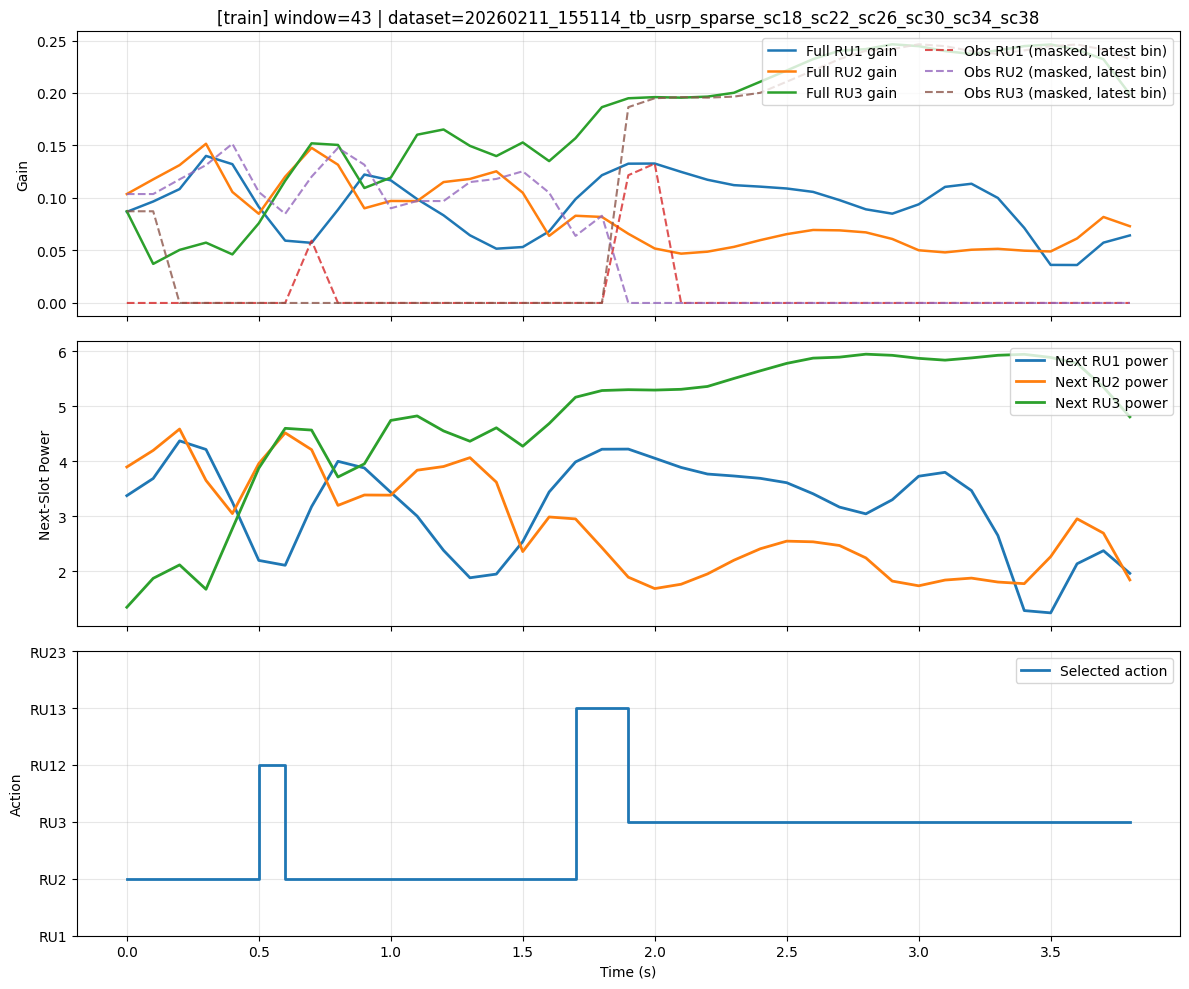

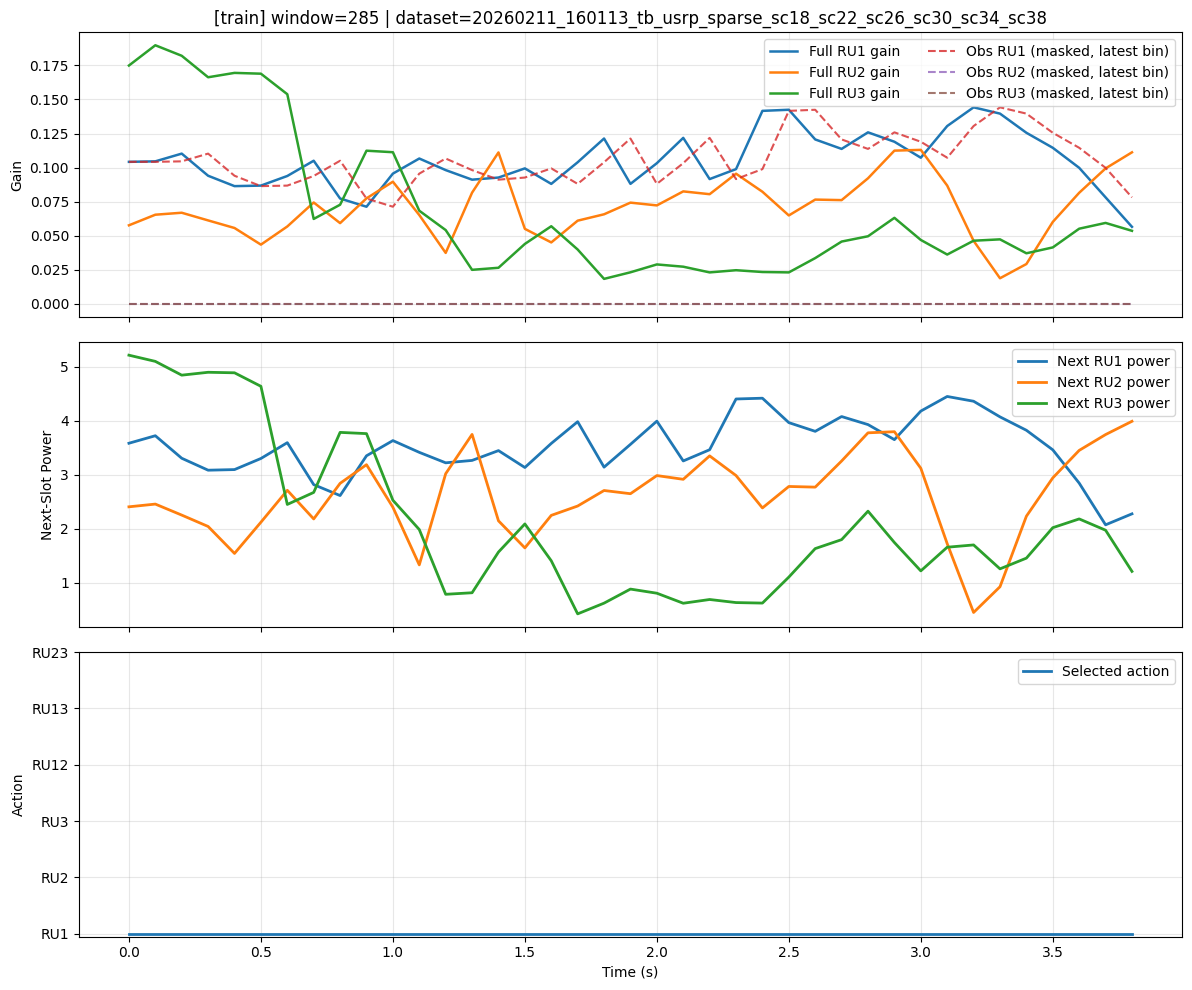

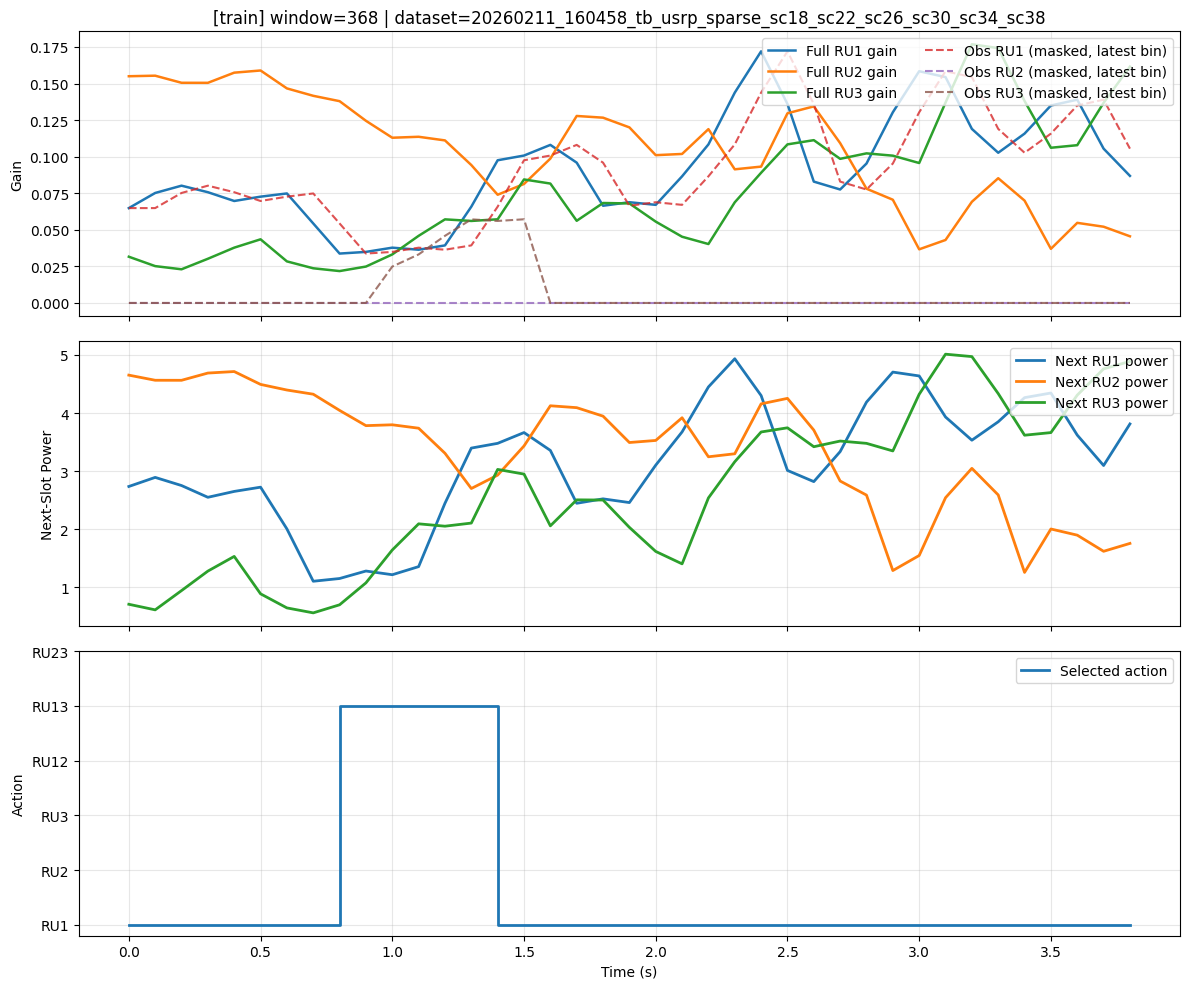

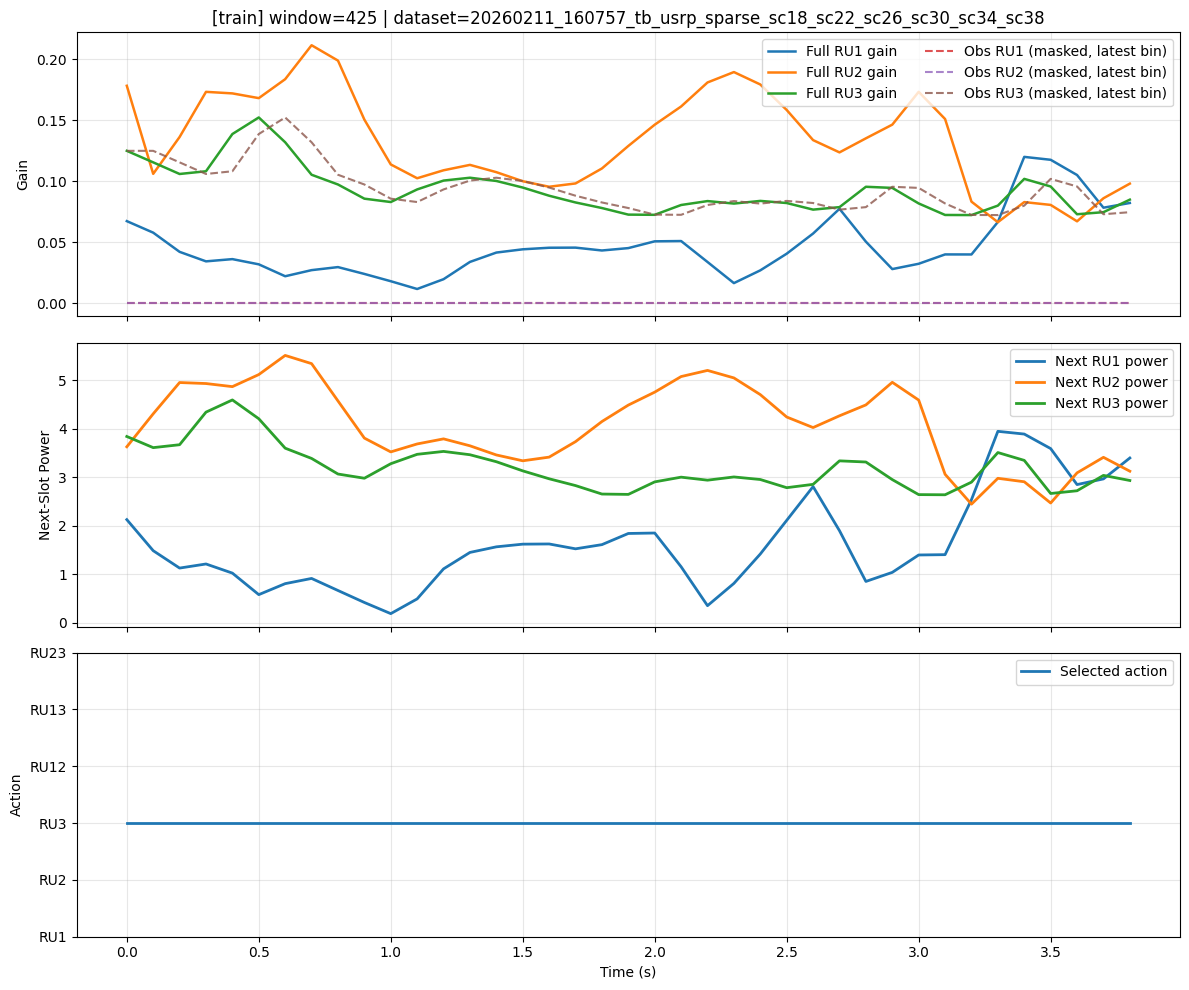

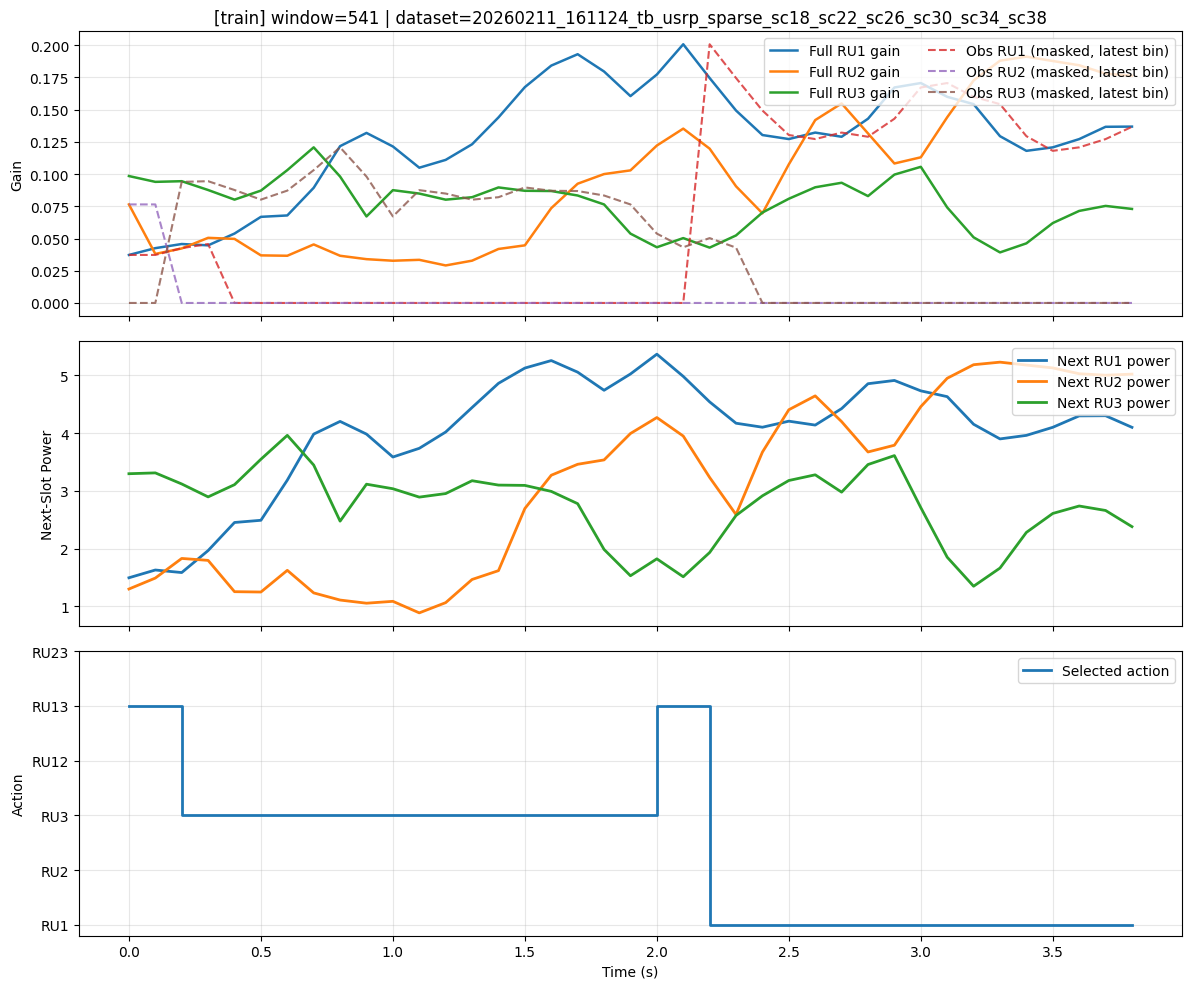

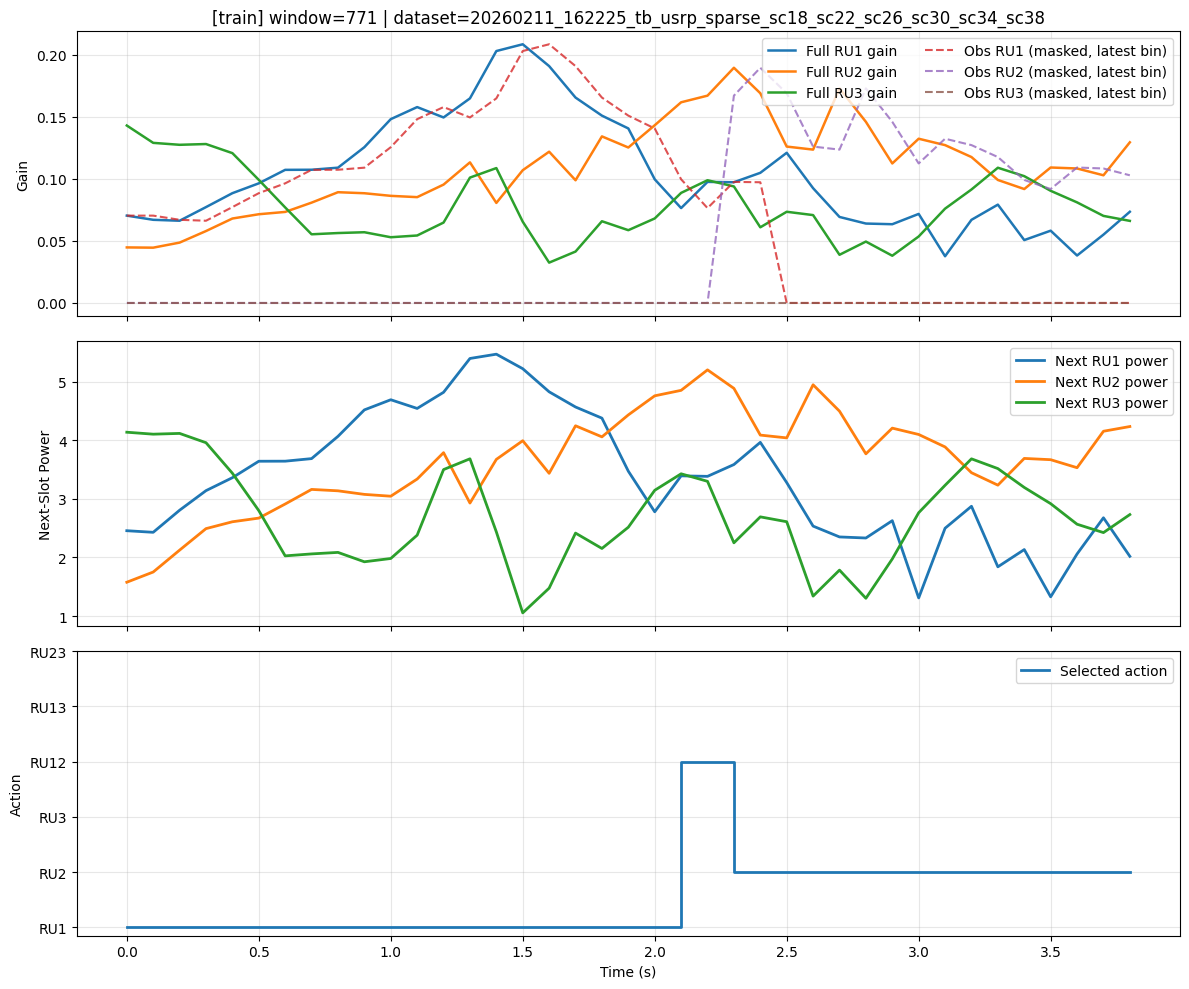

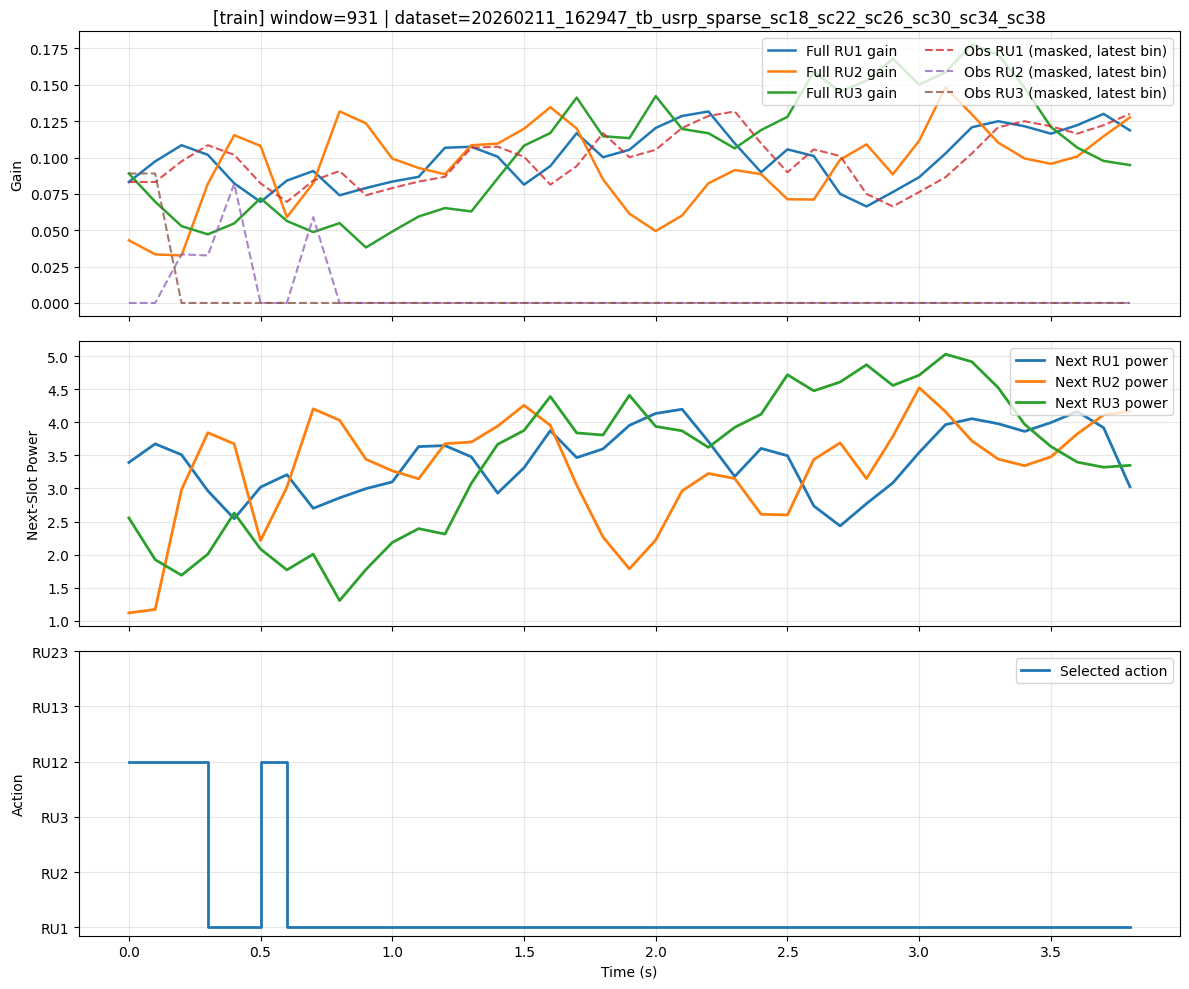

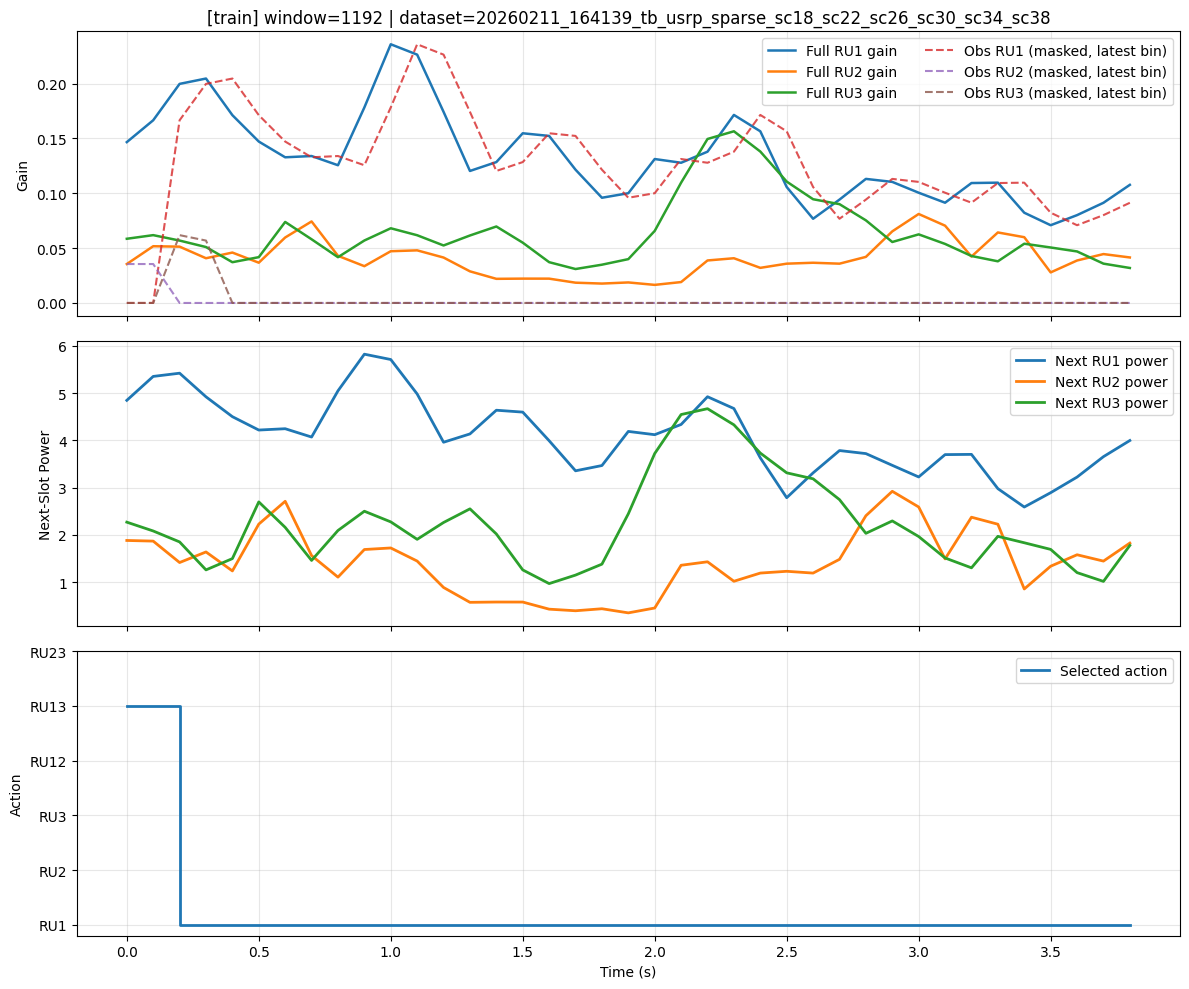

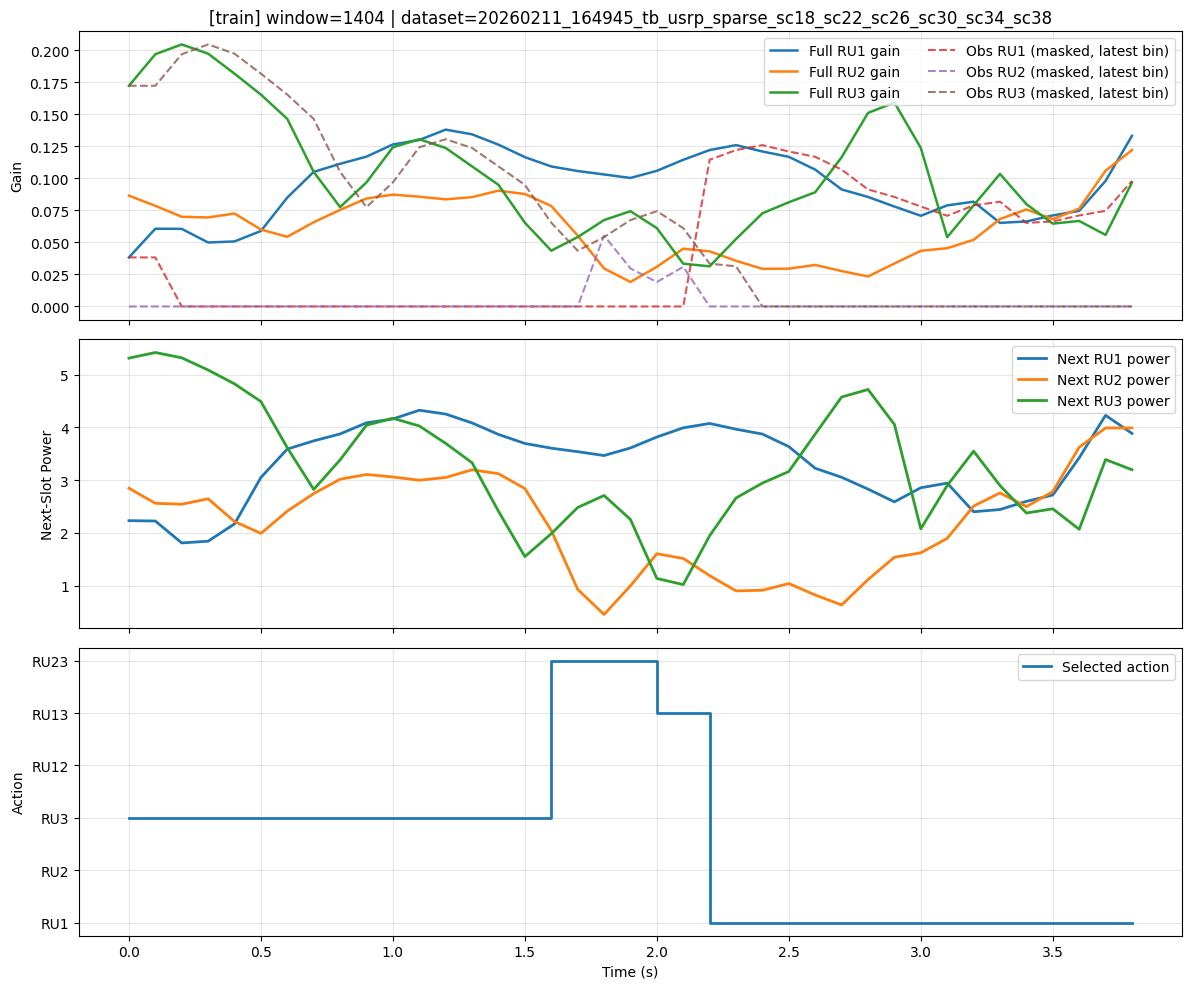

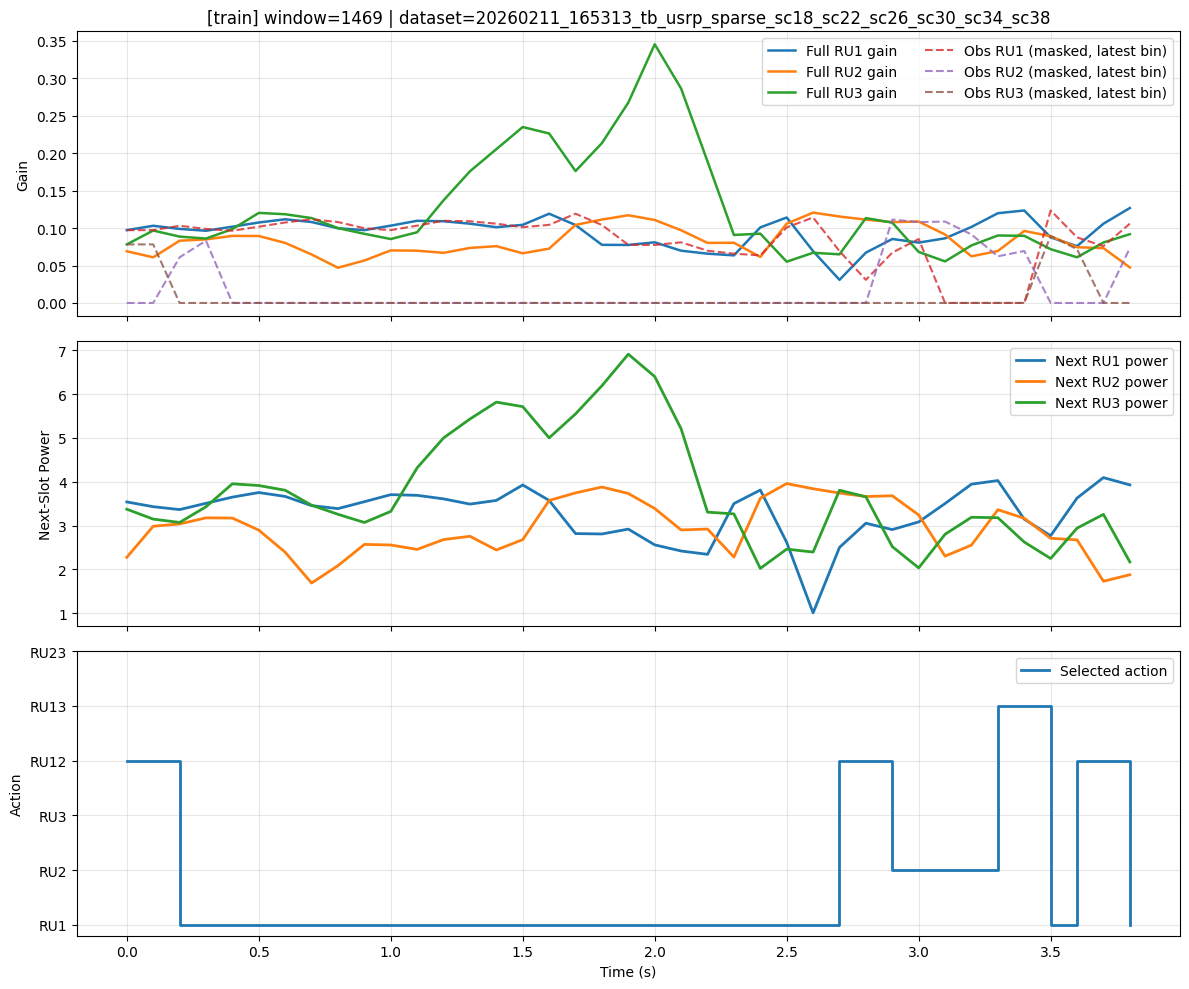

KeyboardInterrupt: 

In [5]:
# Set checkpoint from Final_Train_260316.ipynb (6-action model).
CKPT = "checkpoints_double_dqn_ru_windows4s_easiest/double_dqn_ru_easiest_step001100000.pt"
if not CKPT:
    raise ValueError("Set CKPT to a 6-action checkpoint from Final_Train_260316 first")
main(["--ckpt", CKPT, "--gpu-id", "3", "--num-scenarios", "20"])
